# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 506s 3us/step


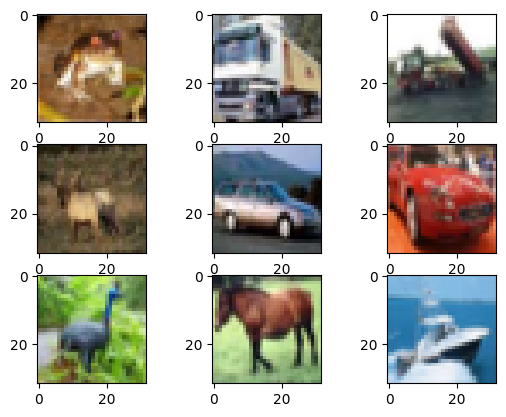

In [3]:
import matplotlib.pyplot as plt

for i in range(9):
	plt.subplot(330 + 1 + i)
	plt.imshow(x_train[i], cmap=plt.get_cmap('gray'))
plt.show()

In [4]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(y_train.shape)
print(y_test.shape)

(50000, 10)
(10000, 10)


In [5]:
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer. 

Use the input as (32,32,3). 

The filter maps can then be flattened to provide features to the classifier. 

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [6]:
from keras.backend import clear_session
clear_session()

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import SGD

model = Sequential()
    # Convolutional front-end: one conv layer with 32 filters of size 3x3, then max pooling
model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform',
                     padding='same', input_shape=(32, 32, 3)))
model.add(MaxPooling2D((2, 2)))
    # Flatten the filter maps into a feature vector for the classifier
model.add(Flatten())
    # Classifier: 100-unit dense layer, then the softmax output layer
model.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [8]:
# Compile
model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(x_train, y_train,
                    epochs=50,
                    batch_size=512,
                    validation_data=(x_test, y_test),
                    verbose=1)


Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.3239 - loss: 1.8917 - val_accuracy: 0.4087 - val_loss: 1.6893
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4373 - loss: 1.5811 - val_accuracy: 0.4660 - val_loss: 1.4860
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4921 - loss: 1.4255 - val_accuracy: 0.5024 - val_loss: 1.3847
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5253 - loss: 1.3392 - val_accuracy: 0.5397 - val_loss: 1.3114
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5502 - loss: 1.2690 - val_accuracy: 0.5374 - val_loss: 1.2933
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5730 - loss: 1.2150 - val_accuracy: 0.5577 - val_loss: 1.2359
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5943 - loss: 1.1587 - val_accuracy: 0.5734 - val_loss: 1.2010
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6121 - loss: 1.1061 - val_accuracy: 0.5911 - v

*   Plot the cross entropy loss curve and the accuracy curve

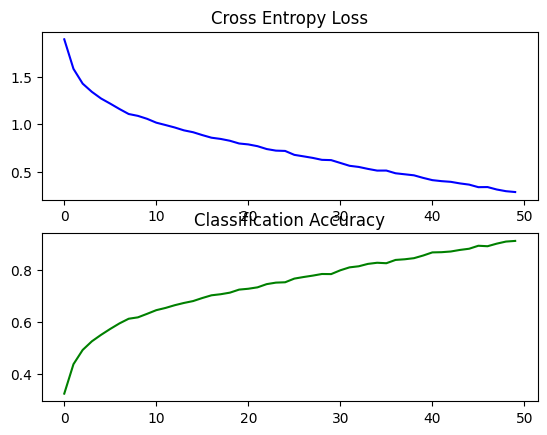

In [9]:
plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history.history['loss'], color='blue', label='train')

plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(history.history['accuracy'], color='green', label='train')
plt.show()

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3. 

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [10]:
from keras.backend import clear_session
clear_session()

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def define_vgg_model():
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [12]:
# Your code here :
vgg_model = define_vgg_model()
vgg_history = vgg_model.fit(x_train, y_train, epochs=50, batch_size=512)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.1505 - loss: 2.2560
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.2601 - loss: 2.0802
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.2896 - loss: 1.9992
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.3267 - loss: 1.9155
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3441 - loss: 1.8747
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3660 - loss: 1.8169
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3773 - loss: 1.7799
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3875 - loss: 1.7519
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3982 - loss: 1.7156
Epoch 10/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4106 - loss: 1.6866
Epoch 11/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4181 - loss: 1.6609
Epoch 12/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy:

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.
 

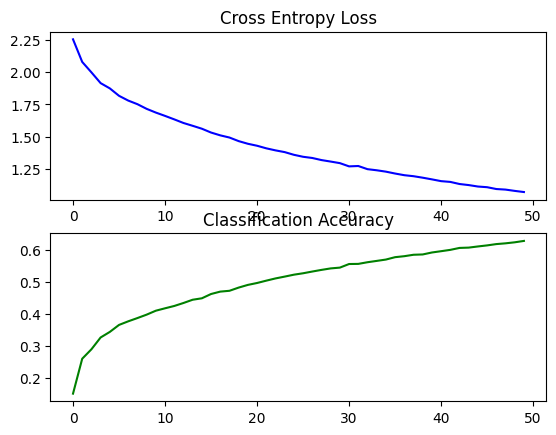

In [13]:
import matplotlib.pyplot as plt

plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(vgg_history.history['loss'], color='blue', label='train')

plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(vgg_history.history['accuracy'], color='green', label='train')
plt.show()

**Comment on the observation**

*(Double-click or enter to edit)*

...

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


In [14]:
predictions = model.predict(x_test)
print(predictions[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[3.9742305e-03 4.6172878e-04 3.6036554e-01 3.6494052e-01 1.2436812e-01
 5.0001852e-02 1.7641220e-02 4.7318800e-04 7.7447683e-02 3.2604480e-04]


In [15]:
predictions = np.argmax(predictions, axis=1)
from sklearn.metrics import confusion_matrix
gt = np.argmax(y_test, axis=1)

confusion_matrix(gt, predictions)

array([[740,  13,  49,  16,  17,   3,  15,  15,  91,  41],
       [ 46, 723,  14,  12,  10,   2,   8,  12,  55, 118],
       [ 84,   5, 517,  65, 114,  39,  75,  68,  21,  12],
       [ 27,  12,  91, 451,  78, 117, 102,  76,  30,  16],
       [ 37,   3,  81,  48, 616,  22,  72, 100,  15,   6],
       [ 16,   6,  94, 192,  78, 420,  52, 105,  25,  12],
       [ 14,   9,  48,  57,  58,  13, 768,  13,   9,  11],
       [ 19,   5,  42,  48,  60,  33,   6, 771,   6,  10],
       [ 73,  40,  12,  10,  10,   7,   7,   9, 795,  37],
       [ 65,  91,  12,  17,   2,   4,   8,  33,  55, 713]])

**Comment here :**

*(Double-click or enter to edit)*
If The standard CIFAR-10 label order is 0 airplane, 1 automobile, 2 bird, 3 cat, 4 deer, 5 dog, 6 frog, 7 horse, 8 ship, 9 truck then we can say that:
        *The animals (bird, cat, deer, dog) are the weak group. They have similar shapes, fur textures and backgrounds, especially at 32×32 pixels.
        *The vehicles (airplane, automobile, ship, truck) do better, but they get mixed up in pairs: airplane↔ship and automobile↔truck.
        *Ship is "over-predicted": 1,243 images were called ship, but only 1,000 are ships. So ship has high recall but lower precision.

*    Print the test accuracy for the trained model.

In [16]:
trained_loss, trained_acc = model.evaluate(x_train, y_train)
print('Trained loss:', trained_loss)
print('Trained accuracy:', trained_acc)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9256 - loss: 0.2544
Trained loss: 0.2544468343257904
Trained accuracy: 0.9256399869918823


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer. 

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling. 

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [17]:
from keras.backend import clear_session
clear_session()

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_vgg(input_shape=(64, 64, 3), num_classes=10):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1: 2 x Conv(64) + MaxPool
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Block 2: 2 x Conv(128) + MaxPool
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Block 3: 2 x Conv(256) + MaxPool
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

x_train = tf.image.resize(x_train, (64, 64)).numpy()
x_test  = tf.image.resize(x_test,  (64, 64)).numpy()


model = build_vgg()

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

In [19]:
model.compile(optimizer='SGD',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, batch_size=512)
predictions = model.predict(x_test)


Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 107s 680ms/step - accuracy: 0.1347 - loss: 2.2993
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 390ms/step - accuracy: 0.1508 - loss: 2.2884
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 389ms/step - accuracy: 0.1853 - loss: 2.2329
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 390ms/step - accuracy: 0.2366 - loss: 2.1083
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 391ms/step - accuracy: 0.2830 - loss: 2.0135
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 391ms/step - accuracy: 0.3140 - loss: 1.9420
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 391ms/step - accuracy: 0.3335 - loss: 1.8813
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 391ms/step - accuracy: 0.3527 - loss: 1.8296
Epoch 9/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 391ms/step - accuracy: 0.3707 - loss: 1.7804
Epoch 10/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 390ms/step - accuracy: 0.3864 - loss: 1.7436
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step


In [20]:
from sklearn.metrics import confusion_matrix
gt = np.argmax(y_test, axis=1)
pred = np.argmax(predictions, axis=1)

confusion_matrix(gt, pred)

array([[390, 111, 151,  12,   3,   0,  16,  15, 238,  64],
       [ 22, 669,  63,  14,   5,   1,  24,  16,  79, 107],
       [ 42,  90, 564,  45,  17,  19,  90,  43,  50,  40],
       [ 11, 119, 316, 208,  28,  53, 120,  23,  50,  72],
       [ 30,  43, 491,  51, 140,   4, 131,  34,  40,  36],
       [ 10, 120, 338, 117,  18, 142,  92,  39,  80,  44],
       [  2,  63, 344,  61,  46,   9, 400,   8,  22,  45],
       [ 22, 106, 285,  45,  36,  19,  44, 281,  43, 119],
       [ 61, 141,  38,  25,   1,   2,   7,  11, 646,  68],
       [ 31, 311,  40,  19,   4,   2,  25,  24, 129, 415]])

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:
An activation function decides a neuron's output from the weighted sum of its inputs. It's needed because it adds non-linearity. Without it, any number of stacked layers collapses into one linear function, so the network could only learn straight-line relationships. With activation functions such as ReLU, sigmoid or tanh, the network can learn complex patterns like edges, shapes and objects in images.

2 - Key Differences between sigmoid and softmax:
*Sigmoid:Each output on its own--Each value between 0 and 1-----------------Binary classification, or multi-label
*Softmax:All outputs together----A probability distribution that sums to 1--Multi-class classification with exactly one correct class
3 - Key Differences between categorical crossentropy and binary crossentropy loss:
use sigmoid with binary cross-entropy for yes/no problems, and softmax with categorical cross-entropy for picking one class out of many
